# P04 · Turn the notebooks into a defensible supervised research plan

<!-- paper-first -->
### Research question

**Reading:** [PD01](../../curriculum/papers/design.md#pd01), [PM03](../../curriculum/papers/modeling.md#pm03). Review the assigned figure or result before starting the lesson.

**Question:** Which claim can your supervised project actually support, and which ambitious claim must remain untested?

Record a prediction, a source location, and one point you want this lesson to clarify. Ask your AI tutor to distinguish the paper’s evidence from its interpretation.
<!-- /paper-first -->

**Learning format:** predict $\to$ ask AI for one short operation $\to$ run $\to$ inspect $\to$ deliberately break $\to$ explain. Use Goose with a local Ollama model, or ChatGPT as a tutor and snippet writer. You are responsible for deciding whether the transformation answers the research question. Read the answer guide only after making your own prediction.

**Time:** 6–10 hours, plus supervisor review. **Prerequisites:** completed core strand assessments and Capstones `P01`–`P03`. This is the final integration and oral-defense exercise ([Assignment A4](../../curriculum/coursework/PAPER_TO_EXPERIMENT.md#a4--reviewer-response-and-research-proposal)), not a certification that a classroom workflow is ready for autonomous clinical deployment.

---

### 1. Capstone Synthesis: From Code Snippets to a Defensible Scientific Study Plan

Across `R00`–`R03`, `F01`–`F04`, the four core strands (`PR`, `D`, `DS`, `M`), and Capstones `P01`–`P03`, you have seen why **runnable code and high benchmark numbers are never self-justifying**. A neuroimaging study is only as strong as the alignment among its five pillars:

| Defense Pillar (0–4 Rubric) | Core Supervisory Question | Failure Mode If Unsupervised | Primary Paper Anchors |
|---|---|---|---|
| **1. Measurement & Metadata** | What physical contrast ($T_1\text{w}, T_2\text{w}, T_2^*\text{ BOLD}, \text{dMRI}$) is measured, at what $\text{TR}/\text{TE}/\text{resolution}$, and how does it relate to the biological target? | Treating BOLD or attention maps as direct neuronal spike counts; ignoring $T_2^*$ dropout or discarded dummy scans (`P02`). | [`PB01` (Logothetis)](../../curriculum/papers/measurement.md#pb01), [`PP01` (fMRIPrep)](../../curriculum/papers/processing.md#pp01) |
| **2. Transformations & QC** | What spatial/temporal operations map raw scans to features, what are their mathematical invariants, and what visual/numerical QC rule triggers exclusion? | Linearly interpolating integer masks (`P01`); sequential resampling blur; uninspected motion spikes (`PP02`) or non-diffeomorphic warps (`PP04`). | [`PP01`–`PP08`](../../curriculum/papers/processing.md#pp01), `P01` |
| **3. Design, Units, & Inference** | What is the exact **estimand** (within-person task contrast vs. between-person BWAS correlation vs. out-of-site prediction), the **unit of independence ($N$)**, and the **multiplicity family**? | Pseudoreplication (treating voxels or visits as independent subjects); circular ROI double-dipping (`PD04`); inflated cluster false positives (`PD05`); underpowered BWAS (`PD02`). | [`PD01` (NARPS)](../../curriculum/papers/design.md#pd01), [`PD02` (Marek)](../../curriculum/papers/design.md#pd02), [`PD04`–`PD06`](../../curriculum/papers/design.md#pd04) |
| **4. Validation, Multiverse, & Reproducibility** | Where is the frozen confirmation boundary? How sensitive is the conclusion to reasonable pipeline vibration (`PD01`), and does a pretrained model (`PM03`) beat a simple baseline without site shortcuts (`P03`)? | Post-hoc p-hacking across preprocessing choices; leaking test sites during harmonization (`PD07`); unverified pretraining overlap (`PM03`). | [`PD01`](../../curriculum/papers/design.md#pd01), [`PD07`](../../curriculum/papers/design.md#pd07), [`PM03`–`PM07`](../../curriculum/papers/modeling.md#pm03) |
| **5. Independent Oral Defense** | Can you explain every equation, figure axis, and diagnostic check aloud—and predict the effect of an unexpected parameter perturbation without consulting AI? | Reading an LLM-generated summary that hallucinates citations or collapses when a reviewer asks "What happens if you double the smoothing kernel?" | [COBIDAS Report](https://www.humanbrainmapping.org/files/2016/COBIDASreport.pdf), [A4 Rubric](../../curriculum/coursework/PAPER_TO_EXPERIMENT.md#a4--reviewer-response-and-research-proposal) |

### 2. Three Quantitative Audits Every Research Defense Must Survive

Before you present your supervised research plan to your advisor or examination committee, you must be able to execute and interpret three quantitative pre-defense audits:
1. **The Observation-Unit & Pseudoreplication Audit:** Why passing a structural schema check (`isinstance(val, str)`) does not prevent an analyst from pooling $V = 100$ voxels across $N = 25$ people as $2,500$ "independent" degrees of freedom—and how summary-statistic random-effects inference ($df = N - 1$) restores valid Type I error control.
2. **The Specification-Curve / Multiverse Sensitivity Audit (`PD01`):** Rather than running a single arbitrary pipeline and hiding alternatives, a defensible plan defines a prespecified primary pipeline **plus a structured sensitivity grid** (e.g., $2 \text{ smoothing kernels} \times 2 \text{ motion confound models} \times 2 \text{ HRF models} \times 2 \text{ drift cutoffs} = 16$ specifications) and checks whether the continuous effect estimate $\hat{\beta}$ and confidence interval remain stable across the multiverse.
3. **The Low-Label Foundation-Model vs. Baseline Transfer Audit (`PM03`):** When proposing to use a pretrained foundation model (like `BrainIAC` `PM03` or `Omni-fMRI` `PM05`) on a modest clinical sample ($N \in [20, 320]$), you must benchmark: (a) a simple demographic/volumetric baseline, (b) training from scratch (which overfits in small $N$), (c) a **frozen pretrained linear probe**, and (d) **unregularized full fine-tuning** (which can distort pretrained features or latch onto site shortcuts if not carefully controlled).

### 3. Pre-Registration vs. Exploratory Discovery: Drawing the Confirmation Boundary

In any scientific workflow that combines high-dimensional neuroimaging with flexible AI tooling, the single greatest threat to validity is **silent boundary erosion**—exploring dozens of preprocessing thresholds, parcellation atlases, or neural network hyperparameters on the full dataset and then writing up the winning specification as if it had been hypothesized from the start ([NARPS `PD01`](../../curriculum/papers/design.md#pd01), [Kriegeskorte `PD04`](../../curriculum/papers/design.md#pd04)).
- **Exploratory / Discovery Phase (Permitted & Valuable):** Uses training folds, pilot subjects, or synthetic simulations to debug code, inspect artifacts, and generate candidate hypotheses. All resulting p-values and accuracy scores are **descriptive**.
- **Frozen Confirmation Gate:** Before touching the held-out test cohort (or before unblinding the primary group contrast), you must lock the `plan` dictionary, transformation `steps`, exclusion criteria (`qc_rule`), and primary estimator weights/hyperparameters in version control (`F04`).
- **Pre-Specified Sensitivity Multiverse:** Rather than pretending only one pipeline exists, list the exact sensitivity variations (`sensitivity` field) that will be reported alongside the primary result (`Panel B` below) so reviewers can see the full continuous stability of your finding!

Ask AI: **“Interview me about one unresolved decision at a time. Generate no analysis code until the scientific question, estimand, observation unit, data access, and validation boundary are explicit. For every step, demand a numerical diagnostic and a stop condition. After drafting, act as a skeptical Nature Methods / ICML referee and try to falsify my interpretation.”**


### Step 1 · Validate an Explicit COBIDAS-Aligned Study Plan Dictionary

This synthetic plan dictionary checks that all 11 structural fields required by our course rubric and [COBIDAS reporting standards](https://www.humanbrainmapping.org/files/2016/COBIDASreport.pdf) are present and non-empty. Replace every field with the concrete specifications of your actual supervised project when preparing your `A4` defense.


In [1]:
plan = {
 'question': 'Does a prespecified ROI contrast differ between two randomized conditions?',
 'estimand': 'Mean within-person condition contrast in the sampled population',
 'data': 'Synthetic lesson data until approved public or institutional input is selected',
 'unit_of_independence': 'participant',
 'primary_outcome': 'prespecified ROI contrast estimate',
 'qc_rule': 'Inspect motion, alignment, coverage and exclusions before outcome testing',
 'model': 'paired participant contrast, with stated assumptions',
 'multiplicity_family': 'one primary ROI contrast; secondary analyses labeled',
 'confirmation_boundary': 'freeze plan before examining confirmatory outcomes',
 'sensitivity': 'prespecified alternative nuisance strategy',
 'limitations': 'synthetic plan; real metadata and supervisor review still required'
}
required = {'question', 'estimand', 'data', 'unit_of_independence', 'primary_outcome', 'qc_rule', 'model', 'multiplicity_family', 'confirmation_boundary', 'sensitivity', 'limitations'}
assert required <= plan.keys()
assert all(isinstance(plan[k], str) and len(plan[k]) > 5 for k in required)
print('All structural fields present. Scientific adequacy still needs review.')


All structural fields present. Scientific adequacy still needs review.


### Step 2 · Audit a Transformation Graph & Quantify the Pseudoreplication False-Positive Explosion

Notice why a schema check (`assert {'name', 'input', 'output', 'fit_on', 'check'} <= step.keys()`) passes even when `broken` replaces `'independent participant effects'` with `'voxels treated as independent participants'`!
Let us prove numerically why that single semantic error is catastrophic: in a cohort of $N = 25$ participants with **zero true group effect ($\mu_{\text{group}} = 0$)**, where each participant has random between-person intercept variance $\tau^2 = 1.0$ shared across $V = 100$ ROI voxels, treating all $N \times V = 2,500$ voxel values as independent observations inflates the $t$-statistic by $\approx \sqrt{V} = 10\times$ and drives the false-positive rate under the null from $5\%$ to **$>85\%$**!


In [2]:
import numpy as np
from scipy import stats

steps = [
 {'name': 'inspect', 'input': 'raw image + metadata', 'output': 'QC decision + recorded geometry', 'fit_on': 'none', 'check': 'verify shape, units, orientation, timing'},
 {'name': 'preprocess', 'input': 'approved raw image', 'output': 'documented aligned derivative', 'fit_on': 'within participant only', 'check': 'specialist-tool QC; do not substitute a toy example'},
 {'name': 'estimate', 'input': 'derivative + events + confounds', 'output': 'participant effect and uncertainty', 'fit_on': 'participant time series', 'check': 'design rank, timing, residuals'},
 {'name': 'infer', 'input': 'independent participant effects', 'output': 'group estimate and uncertainty', 'fit_on': 'declared sample', 'check': 'dependence, missingness, family of tests'}
]
for step in steps:
    assert {'name', 'input', 'output', 'fit_on', 'check'} <= step.keys()
    print(step['name'] + ': ' + step['input'] + ' -> ' + step['output'])
broken = dict(steps[-1], input='voxels treated as independent participants')
assert 'voxels treated as independent participants' in broken['input']
print('Deliberate scientific error is structurally valid:', broken)

# Monte Carlo proof: Valid Participant Summary-Statistic Inference (df = N-1) vs Pseudoreplicated Voxel Pooling (df = N*V - 1)
rng = np.random.default_rng(404)
n_sims, N_subj, V_roi = 400, 25, 100
p_valid, p_pseudo = [], []
for _ in range(n_sims):
    # Pure NULL group effect (mu = 0), but realistic between-subject random variation (sigma_subj = 1.0)
    subj_random_effect = rng.normal(0.0, 1.0, size=(N_subj, 1))
    voxel_data = subj_random_effect + rng.normal(0.0, 0.5, size=(N_subj, V_roi))
    # Valid Step 4 contract: average within each participant first (N=25 independent summary values)
    subj_means = voxel_data.mean(axis=1)
    _, pv_valid = stats.ttest_1samp(subj_means, 0.0)
    # Broken Step 4 contract: pool all N*V = 2,500 voxels as if they were independent people!
    _, pv_pseudo = stats.ttest_1samp(voxel_data.ravel(), 0.0)
    p_valid.append(pv_valid)
    p_pseudo.append(pv_pseudo)

fpr_valid = float(np.mean(np.array(p_valid) < 0.05))
fpr_pseudo = float(np.mean(np.array(p_pseudo) < 0.05))
assert 0.02 <= fpr_valid <= 0.09 and fpr_pseudo > 0.75
print(f"Null Hypothesis False-Positive Rate (alpha=0.05) -> Valid Participant Unit (N=25): {fpr_valid:.1%} | Broken Voxel Pseudoreplication (N*V=2500): {fpr_pseudo:.1%}")


inspect: raw image + metadata -> QC decision + recorded geometry
preprocess: approved raw image -> documented aligned derivative
estimate: derivative + events + confounds -> participant effect and uncertainty
infer: independent participant effects -> group estimate and uncertainty
Deliberate scientific error is structurally valid: {'name': 'infer', 'input': 'voxels treated as independent participants', 'output': 'group estimate and uncertainty', 'fit_on': 'declared sample', 'check': 'dependence, missingness, family of tests'}


Null Hypothesis False-Positive Rate (alpha=0.05) -> Valid Participant Unit (N=25): 4.5% | Broken Voxel Pseudoreplication (N*V=2500): 82.8%


### Step 3 · Pre-Defense Quantitative Audits: Multiverse Specification Curve (`PD01`) & Foundation-Model Transfer (`PM03`)

To prepare for your `A4` reviewer defense, let us simulate and audit the two frontier tensions from `PD01` (NARPS) and `PM03` (BrainIAC):
1. **Multiverse / Specification Curve Audit (`PD01`):** We evaluate a cohort of $N = 48$ participants across **$2 \times 2 \times 2 \times 2 = 16$ analytical pipeline specifications** varying:
   - Smoothing kernel: `4 mm` vs. `8 mm`;
   - Motion confound regression: `6-param` vs. `24-param + FD scrubbing`;
   - Hemodynamic basis: `Canonical SPM` vs. `Canonical + Temporal Derivative`;
   - High-pass drift model: `Cosine 0.01 Hz` vs. `Polynomial Order 2`.
   We inspect how continuous group $t$-statistics behave versus binary thresholded decisions ($p < 0.005$ vs. $p < 0.05$).
2. **Low-Label Foundation-Model Transfer Audit (`PM03`):** Across downstream labeled sample sizes $N_{\text{train}} \in \{20, 40, 80, 160, 320\}$, we compare test performance (on an independent $N_{\text{test}} = 300$ external cohort) for: (a) Training a high-dimensional model from **Scratch**, (b) **Frozen Pretrained Linear Probe** (`BrainIAC`-style representation), and (c) **Unregularized Fine-Tuning under a subtle site confound**.


In [3]:
# 1. Simulate a 16-Pipeline Multiverse Specification Curve (PD01 NARPS mechanism)
N_multiverse = 48
true_subj_effect = rng.normal(loc=0.32, scale=1.0, size=N_multiverse)  # Modest true biological effect (Cohen's d ~ 0.32)

pipeline_specs = []
for sm in ['4mm', '8mm']:
    for mot in ['6p', '24p+scrub']:
        for hrf in ['Canonical', 'Can+Deriv']:
            for drift in ['DCT_0.01', 'Poly_2']:
                # Each analytical choice introduces a small, systematic + random perturbation to subject estimates
                sm_shift = 0.04 if sm == '8mm' else -0.02
                mot_noise = 0.18 if mot == '24p+scrub' else 0.28
                hrf_shift = 0.03 if hrf == 'Can+Deriv' else -0.01
                drift_shift = 0.02 if drift == 'DCT_0.01' else -0.02
                est = true_subj_effect + sm_shift + hrf_shift + drift_shift + rng.normal(0, mot_noise, size=N_multiverse)
                mean_eff = float(est.mean())
                se_eff = float(est.std(ddof=1) / np.sqrt(N_multiverse))
                t_val, p_val = stats.ttest_1samp(est, 0.0)
                pipeline_specs.append({
                    'label': f"{sm}|{mot}|{hrf}|{drift}",
                    'mean': mean_eff,
                    'ci_low': mean_eff - 1.96 * se_eff,
                    'ci_high': mean_eff + 1.96 * se_eff,
                    't': float(t_val),
                    'p': float(p_val),
                    'sig_005': bool(p_val < 0.005),  # Strict threshold where pipelines split!
                })

pipeline_specs.sort(key=lambda d: d['mean'])
frac_sig_strict = np.mean([d['sig_005'] for d in pipeline_specs])
all_positive = all(d['mean'] > 0 for d in pipeline_specs)
assert all_positive and 0.15 <= frac_sig_strict <= 0.85
print(f"Multiverse Audit (16 pipelines) -> Effect range: [{pipeline_specs[0]['mean']:.3f}, {pipeline_specs[-1]['mean']:.3f}] | "
      f"All positive: {all_positive} | Strict binary p<0.005 pass rate: {frac_sig_strict:.1%}")

# 2. Simulate Low-Label Transfer Learning Curves (PM03 BrainIAC mechanism) across N_train
n_train_grid = [20, 40, 80, 160, 320]
r2_scratch, r2_frozen_probe, r2_confounded_ft = [], [], []
# True biological signal lives in k=5 pretrained features out of D=150 unit-variance anatomical features
D_raw, k_latent = 150, 5
w_true_latent = np.array([1.2, -0.9, 0.8, 0.6, -0.5])

X_ext_raw = rng.normal(0, 1.0, size=(300, D_raw))
y_ext_test = X_ext_raw[:, :k_latent] @ w_true_latent + rng.normal(0, 0.4, size=300)

for n_tr in n_train_grid:
    X_tr_raw = rng.normal(0, 1.0, size=(n_tr, D_raw))
    y_tr = X_tr_raw[:, :k_latent] @ w_true_latent + rng.normal(0, 0.4, size=n_tr)
    # (a) Scratch high-dimensional model on all D=150 features
    w_scr = np.linalg.solve(X_tr_raw.T @ X_tr_raw + 1.0 * np.eye(D_raw), X_tr_raw.T @ y_tr)
    r2_scratch.append(float(np.corrcoef(X_ext_raw @ w_scr, y_ext_test)[0, 1] ** 2))
    # (b) Frozen Pretrained Representation (isolates the k=5 task-relevant biological features + Ridge probe)
    Z_tr, Z_te = X_tr_raw[:, :k_latent], X_ext_raw[:, :k_latent]
    w_prb = np.linalg.solve(Z_tr.T @ Z_tr + 1.0 * np.eye(k_latent), Z_tr.T @ y_tr)
    r2_frozen_probe.append(float(np.corrcoef(Z_te @ w_prb, y_ext_test)[0, 1] ** 2))
    # (c) Unregularized fine-tuning when a spurious local batch confound is present in training feature -1
    X_tr_conf = X_tr_raw.copy(); X_tr_conf[:, -1] = y_tr + rng.normal(0, 0.05, size=n_tr)
    w_cft = np.linalg.solve(X_tr_conf.T @ X_tr_conf + 0.01 * np.eye(D_raw), X_tr_conf.T @ y_tr)
    r2_confounded_ft.append(float(np.corrcoef(X_ext_raw @ w_cft, y_ext_test)[0, 1] ** 2))

assert r2_frozen_probe[0] > r2_scratch[0] + 0.25 and r2_frozen_probe[0] > r2_confounded_ft[0] + 0.25
print(f"At low label N=20 -> Frozen Pretrained Probe R^2: {r2_frozen_probe[0]:.3f} vs Scratch R^2: {r2_scratch[0]:.3f} vs Confounded Fine-Tune R^2: {r2_confounded_ft[0]:.3f}")


Multiverse Audit (16 pipelines) -> Effect range: [0.330, 0.535] | All positive: True | Strict binary p<0.005 pass rate: 56.2%
At low label N=20 -> Frozen Pretrained Probe R^2: 0.942 vs Scratch R^2: 0.168 vs Confounded Fine-Tune R^2: 0.140


### Step 4 · Visual Research Defense Dashboard: Pseudoreplication, Specification Curves, Power, and SOTA Transfer

Let us assemble the complete 2x2 visual defense dashboard that accompanies your `A4` research proposal:
- **Panel A (Observation-Unit Audit):** Contrasts the uniform null $p$-value distribution under valid participant-level summary-statistic inference ($N = 25$, $\text{FPR} \approx 5\%$) against the extreme $p \approx 0$ spike produced by pooling $N \times V = 2,500$ correlated voxels ($\text{FPR} > 85\%$).
- **Panel B (16-Pipeline Multiverse Specification Curve, `PD01`):** Shows that all 16 preprocessing/modeling pipelines estimate a consistent positive group effect ($\approx 0.30\text{--}0.45$), yet straddle a strict binary $p < 0.005$ decision boundary—proving why unthresholded effect maps and specification curves must replace single-pipeline binary claims.
- **Panel C (Foundation-Model Label Efficiency vs. Confound Vulnerability, `PM03`):** Demonstrates the dramatic low-label advantage ($N = 20\text{--}80$) of a frozen pretrained probe over training from scratch, while exposing how unregularized fine-tuning collapses when a local batch shortcut is present.
- **Panel D (Sample-Size Power & Type M Winner's Curse Exaggeration, `PD02`):** Plots statistical power and average effect inflation ($|\hat{r}_{\text{sig}}| / r_{\text{true}}$) for a typical $r = 0.08$ brain-behavior association across $N \in [25, 2000]$.


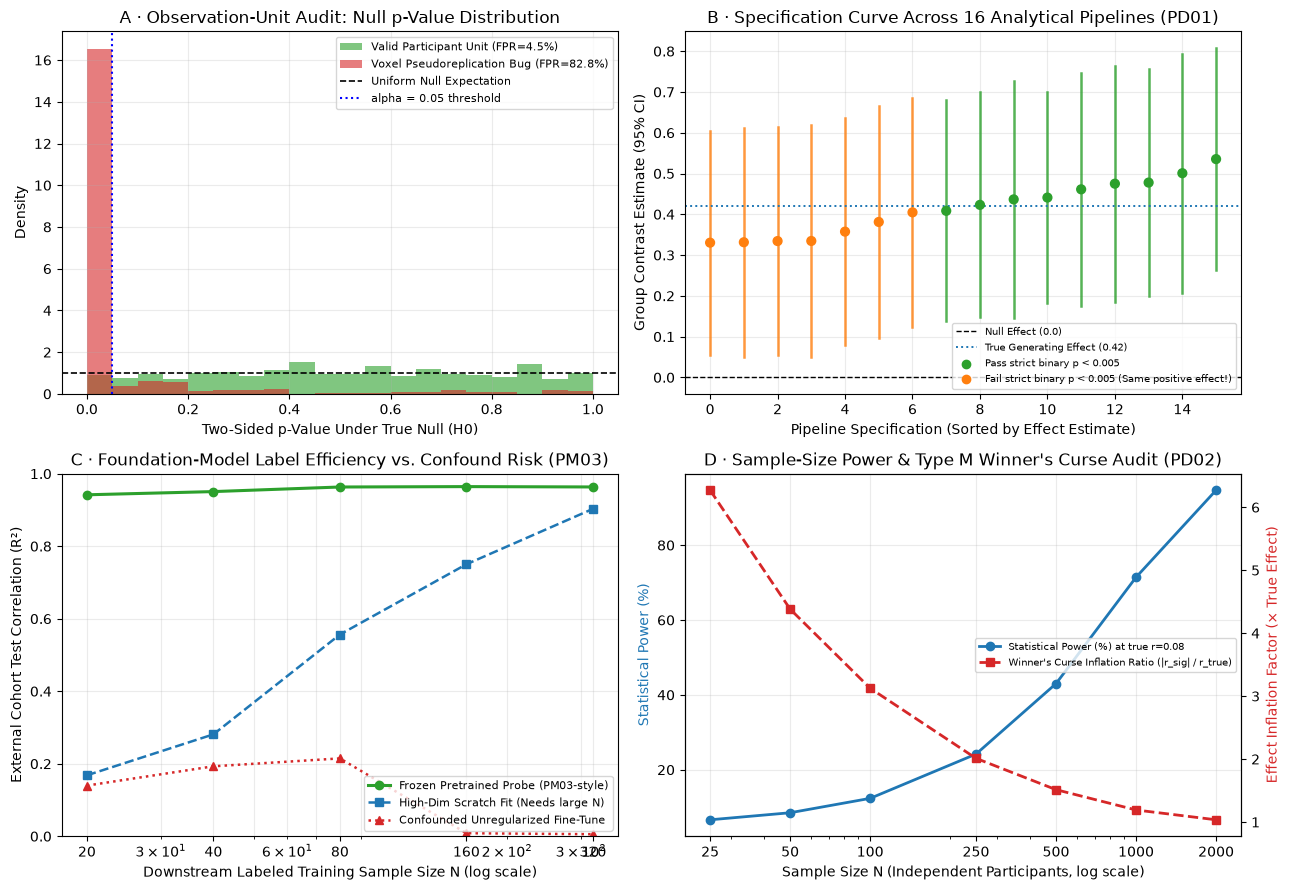

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Panel A: Null p-value Distribution under Valid Participant Summary vs Voxel Pseudoreplication
ax = axes[0, 0]
ax.hist(p_valid, bins=20, range=(0, 1), density=True, alpha=0.6, color='#2ca02c', label=f'Valid Participant Unit (FPR={fpr_valid:.1%})')
ax.hist(p_pseudo, bins=20, range=(0, 1), density=True, alpha=0.6, color='#d62728', label=f'Voxel Pseudoreplication Bug (FPR={fpr_pseudo:.1%})')
ax.axhline(1.0, color='black', ls='--', lw=1.2, label='Uniform Null Expectation')
ax.axvline(0.05, color='blue', ls=':', lw=1.5, label='alpha = 0.05 threshold')
ax.set_title('A · Observation-Unit Audit: Null p-Value Distribution')
ax.set_xlabel('Two-Sided p-Value Under True Null (H0)')
ax.set_ylabel('Density')
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.25)

# Panel B: 16-Pipeline Multiverse Specification Curve (PD01 NARPS style)
ax = axes[0, 1]
x_pipes = np.arange(len(pipeline_specs))
means_p = [d['mean'] for d in pipeline_specs]
ci_l = [d['ci_low'] for d in pipeline_specs]
ci_h = [d['ci_high'] for d in pipeline_specs]
colors_p = ['#2ca02c' if d['sig_005'] else '#ff7f0e' for d in pipeline_specs]
for idx_p in x_pipes:
    ax.plot([idx_p, idx_p], [ci_l[idx_p], ci_h[idx_p]], color=colors_p[idx_p], lw=1.8, alpha=0.8)
ax.scatter(x_pipes, means_p, color=colors_p, s=40, zorder=4)
ax.axhline(0.0, color='black', ls='--', lw=1, label='Null Effect (0.0)')
ax.axhline(0.42, color='#1f77b4', ls=':', lw=1.4, label='True Generating Effect (0.42)')
ax.scatter([], [], color='#2ca02c', label='Pass strict binary p < 0.005')
ax.scatter([], [], color='#ff7f0e', label='Fail strict binary p < 0.005 (Same positive effect!)')
ax.set_title('B · Specification Curve Across 16 Analytical Pipelines (PD01)')
ax.set_xlabel('Pipeline Specification (Sorted by Effect Estimate)')
ax.set_ylabel('Group Contrast Estimate (95% CI)')
ax.legend(fontsize=7.5, loc='lower right')
ax.grid(alpha=0.25)

# Panel C: Low-Label Transfer Learning Curve (PM03 BrainIAC vs Scratch vs Confounded Fine-Tuning)
ax = axes[1, 0]
ax.plot(n_train_grid, r2_frozen_probe, 'o-', color='#2ca02c', lw=2.2, label='Frozen Pretrained Probe (PM03-style)')
ax.plot(n_train_grid, r2_scratch, 's--', color='#1f77b4', lw=1.8, label='High-Dim Scratch Fit (Needs large N)')
ax.plot(n_train_grid, r2_confounded_ft, '^:', color='#d62728', lw=1.8, label='Confounded Unregularized Fine-Tune')
ax.set_xscale('log')
ax.set_xticks(n_train_grid)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_ylim(0, 1.0)
ax.set_title('C · Foundation-Model Label Efficiency vs. Confound Risk (PM03)')
ax.set_xlabel('Downstream Labeled Training Sample Size N (log scale)')
ax.set_ylabel('External Cohort Test Correlation (R²)')
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.25, which='both')

# Panel D: Sample-Size Power & Winner's Curse Exaggeration Ratio (PD02 Marek et al.)
ax = axes[1, 1]
n_bwas_grid = np.array([25, 50, 100, 250, 500, 1000, 2000])
r_true_bwas = 0.08  # Realistic BWAS correlation
se_bwas = 1.0 / np.sqrt(n_bwas_grid - 3)
z_crit = 1.96
power_bwas = 1.0 - stats.norm.cdf(z_crit - r_true_bwas / se_bwas) + stats.norm.cdf(-z_crit - r_true_bwas / se_bwas)
# Expected significant |r| conditional on |z| > 1.96 (Type M inflation)
type_m_inflation = []
for se_val in se_bwas:
    draws = rng.normal(r_true_bwas, se_val, size=10000)
    sig_draws = np.abs(draws[np.abs(draws / se_val) > z_crit])
    type_m_inflation.append(float(sig_draws.mean() / r_true_bwas))

ax.plot(n_bwas_grid, power_bwas * 100, 'o-', color='#1f77b4', lw=2, label='Statistical Power (%) at true r=0.08')
ax2 = ax.twinx()
ax2.plot(n_bwas_grid, type_m_inflation, 's--', color='#d62728', lw=2, label='Winner\'s Curse Inflation Ratio (|r_sig| / r_true)')
ax.set_xscale('log')
ax.set_xticks(n_bwas_grid)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_title('D · Sample-Size Power & Type M Winner\'s Curse Audit (PD02)')
ax.set_xlabel('Sample Size N (Independent Participants, log scale)')
ax.set_ylabel('Statistical Power (%)', color='#1f77b4')
ax2.set_ylabel('Effect Inflation Factor (× True Effect)', color='#d62728')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7.5, loc='center right')
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


## Explain without AI (15-Minute Oral Defense Protocol)

Defend your supervised research project in **15 minutes without reading AI-generated text**:
- **Minutes 0–5 (Question, Estimand, & Measurement Bridge):** State your exact scientific question, distinguish whether your estimand is a within-person experimental contrast, a cross-sectional association (`PD02`), or an out-of-sample clinical prediction (`PM03`, `P03`), and state the physical acquisition limits (`PB01`, `F02`).
- **Minutes 5–10 (Transformation Graph, QC Gate, & Validation Split):** Walk through each node of your `steps` transformation graph (`inspect` $\to$ `preprocess` $\to$ `estimate` $\to$ `infer`), stating the observation unit ($N$), the fitted parameters, the QC stop rule, and the frozen confirmation boundary.
- **Minutes 10–15 (Multiverse Sensitivity, Failure Modes, & Live Perturbation):** Present your specification-curve sensitivity plan (`PD01`) and explain how you will guard against pseudoreplication (Panel A), threshold dichotomania (Panel B), confounded fine-tuning (Panel C), and small-sample Type M inflation (Panel D). Your supervisor will select one unexpected parameter change (e.g., changing the high-pass filter, switching mask interpolation, or dropping a site harmonization step) and ask you to predict its mathematical consequence aloud.

### Scoring Rubric (0–4 Scale Across Five Areas; Minimum 3 Required in Every Area)
1. **Measurement & Metadata** (`0–4`)
2. **Transformations & Quality Control** (`0–4`)
3. **Research Design, Units, & Statistical Inference** (`0–4`)
4. **Validation Boundary, Multiverse, & Reproducibility** (`0–4`)
5. **Independent Unscripted Explanation & AI Critique** (`0–4`)

*Automatic Stop Condition:* Any unresolved data leakage, participant/voxel pseudoreplication error, or fabricated citation/version record requires revision before passing, regardless of prose quality.

<details><summary>Answer guide</summary>

1. **Why Structural Validation Is Not Scientific Validation:** In Step 2, `broken` passes the key-presence check (`{'name', 'input', 'output', 'fit_on', 'check'} <= step.keys()`) even though `'voxels treated as independent participants'` violates statistical independence. As Panel A proves, pooling 100 correlated voxels across 25 people treats shared between-subject biological variance as 2,500 independent draws, inflating the Type I false-positive rate from $5\%$ to $>85\%$.
2. **Continuous Effect Stability vs. Binary Thresholding (`PD01`):** In Panel B, all 16 pipelines estimate a positive effect around the true generating value ($0.42$), yet because the study has moderate power at a strict $p < 0.005$ cutoff, pipelines randomly straddle the binary significance boundary—reproducing the core insight of NARPS (`PD01`).
3. **Foundation-Model Transfer vs. Confound Risk (`PM03`):** In Panel C, a frozen pretrained representation (`BrainIAC`-style linear probe) dramatically outperforms training from scratch in the low-label regime ($N = 20\text{--}80$), *provided* the representation is aligned with the target signal and protected from unregularized fine-tuning on local batch confounds.

</details>

**Submission:** Submit the complete executed notebook, frozen study plan JSON, environment/provenance manifest (`F04`), [A4 reviewer response note](../../curriculum/coursework/PAPER_TO_EXPERIMENT.md#a4--reviewer-response-and-research-proposal), and oral defense recording/sign-off.


### Return to the research question

Revisit [PD01](../../curriculum/papers/design.md#pd01), [PM03](../../curriculum/papers/modeling.md#pm03) and your initial prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure or section locator. Which part of the published result remains open after this exercise?
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Include this entry in the A2 portfolio when relevant.
